# Bolsa Familia e evasao escolar

## Estimacao do ATT com pareamento, IPW e escores logit/ML

**Disciplina:** Avaliacao de Politicas Publicas com Dados  
**Atividade 03:** selecao nos observaveis, pareamento e escore de propensao

Esta entrega replica e estende a analise da AIBF II realizada em aula. O
desfecho original, frequencia nos ultimos sete dias, e substituido por
**evasao escolar**. Todos os metodos respondem a mesma pergunta:

> Entre as criancas e adolescentes beneficiarios que estudavam no ano
> anterior, qual foi o efeito medio de viver em um domicilio beneficiario
> do Bolsa Familia sobre a probabilidade de abandonar a escola?

O estimando e o **ATT**, expresso em pontos percentuais. A analise compara
pareamento 1:1 e ponderacao IPW para ATT, usando escores estimados por
regressao logistica e por random forest calibrado. SMD e love plots avaliam
balanceamento. A interpretacao causal e explicitamente condicionada a
ignorabilidade, positividade, consistencia e ausencia de interferencia.

## 1. Desenho, dados e hipoteses

A AIBF II e observacional. A unidade e a pessoa de 6 a 17 anos. O tratamento
ocorre no domicilio: `D=1` se algum morador e titular do cartao do Bolsa
Familia. O grupo de comparacao e apenas o **controle cadastrado (C1)**; o
controle nao cadastrado (C2) e excluido porque passou por um processo de
selecao diferente para o Cadastro Unico.

O desfecho `dropout` vale 1 para abandono e 0 para permanencia, entre pessoas
que estudavam no ano anterior. Portanto, ATT positivo significa aumento da
evasao e ATT negativo significa reducao.

O conjunto de ajuste preserva as covariaveis pre-tratamento usadas na aula:
idade, sexo, escolaridade do chefe, numero de moradores, comodos,
dormitorios e agua canalizada. Elas representam demografia e vulnerabilidade
domiciliar. Nao ajustamos por frequencia, faltas, serie atual ou outras
variaveis escolares contemporaneas, pois podem ser consequencias do
tratamento ou do proprio processo que produz o desfecho.

Identificacao requer:

1. **Ignorabilidade:** `(Y(0), Y(1)) independent of D | X`;
2. **Positividade:** perfis tratados possuem controles C1 comparaveis;
3. **Consistencia:** o tratamento observado corresponde a uma versao
   suficientemente bem definida do programa;
4. **SUTVA/nao interferencia:** o beneficio de uma familia nao altera o
   resultado potencial de outra.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.neighbors import NearestNeighbors
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")
CORES = {"antes": "#C23B33", "pareamento": "#167D8D", "ipw": "#D18B18"}
RANDOM_STATE = 42

In [2]:
caminho = Path("data/aibf_ii_educacao.csv")
if not caminho.exists():
    caminho = Path.cwd() / "data/aibf_ii_educacao.csv"
aibf = pd.read_csv(caminho)
print(f"Base bruta: {aibf.shape[0]:,} pessoas, {aibf['cod_dtm'].nunique():,} domicilios")

Base bruta: 56,367 pessoas, 11,372 domicilios


In [3]:
# Tratamento domiciliar: existe ao menos um titular do cartao no domicilio.
tratamento_dom = (aibf.groupby("cod_dtm")["s02a10"]
                   .transform(lambda s: int((s == 1).any())))
aibf["D"] = tratamento_dom
aibf["feminino"] = (aibf["s02ad"] == 2).astype(float)
aibf["agua"] = (aibf["agua_canalizada"] == 1).astype(float)

COVARIAVEIS = ["s02af", "feminino", "educ_chefe", "n_moradores",
               "n_comodos", "n_dormitorios", "agua"]
ROTULOS = {
    "s02af": "Idade", "feminino": "Sexo feminino",
    "educ_chefe": "Escolaridade do chefe", "n_moradores": "Moradores",
    "n_comodos": "Comodos", "n_dormitorios": "Dormitorios",
    "agua": "Agua canalizada"
}

# C1 e beneficiarios somente; idade escolar, dropout observado e casos completos.
filtro = (
    aibf["estrato_amostral"].isin(["beneficiario", "controle"])
    & aibf["s02af"].between(6, 17)
    & aibf["dropout"].notna()
)
dados = (aibf.loc[filtro, ["cod_dtm", "D", "dropout", *COVARIAVEIS]]
         .dropna()
         .rename(columns={"dropout": "Y"})
         .reset_index(drop=True))

# Checagens que impedem mudancas silenciosas no recorte.
assert set(dados["D"].unique()) == {0, 1}
assert set(dados["Y"].unique()) <= {0, 1}
assert dados[COVARIAVEIS].notna().all().all()
resumo_amostra = (dados.groupby("D")["Y"]
                  .agg(n="size", domicilios=lambda s: dados.loc[s.index, "cod_dtm"].nunique(),
                       evasao="mean")
                  .rename(index={0: "Controle C1", 1: "Beneficiario"}))
resumo_amostra

,n,domicilios,evasao
D,,,
Controle C1,2430,1506,0.0786
Beneficiario,6054,3150,0.0689


A exclusao de observacoes sem `dropout` nao e mero detalhe operacional: o
desfecho so e definido para quem estudava no ano anterior. Assim, o ATT se
refere a essa subpopulacao, nao a todas as criancas pobres. Se o Bolsa
Familia afetou anteriormente a probabilidade de estar nessa subpopulacao,
condiciona-la pode introduzir selecao; a base transversal nao permite
eliminar essa ameaca.

## 2. Associacao bruta

Antes do ajuste, comparamos as medias observadas. Essa diferenca mistura o
efeito do programa e a selecao de familias mais vulneraveis para o beneficio.

In [4]:
media_trat = dados.loc[dados.D == 1, "Y"].mean()
media_ctrl = dados.loc[dados.D == 0, "Y"].mean()
diferenca_bruta = media_trat - media_ctrl
pd.DataFrame({
    "medida": ["Evasao beneficiarios", "Evasao controle C1", "Diferenca bruta"],
    "proporcao": [media_trat, media_ctrl, diferenca_bruta],
    "pontos_percentuais": 100 * np.array([media_trat, media_ctrl, diferenca_bruta])
})

,medida,proporcao,pontos_percentuais
0,Evasao beneficiarios,0.0689,6.8880
1,Evasao controle C1,0.0786,7.8601
2,Diferenca bruta,-0.0097,-0.9721


## 3. Escores de propensao: logistica e machine learning

Estimamos `e(X)=P(D=1|X)` por dois modelos. A logistica impoe uma forma
funcional aditiva e linear no logito. O random forest captura nao linearidades
e interacoes, mas suas probabilidades podem ser inadequadas para ponderacao;
por isso usamos folhas regularizadas, calibracao sigmoide e predicoes
**out-of-fold** em cinco particoes. A logistica tambem e avaliada out-of-fold
para uma comparacao simetrica.

AUC e calibracao sao apresentados como diagnosticos auxiliares. O criterio
causal decisivo sera o balanceamento produzido pelo uso do escore, nao a
capacidade de prever tratamento.

In [5]:
X = dados[COVARIAVEIS]
D = dados["D"].astype(int).to_numpy()
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

modelo_logit = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
)
modelo_rf_base = RandomForestClassifier(
    n_estimators=300, min_samples_leaf=25, max_features="sqrt",
    n_jobs=-1, random_state=RANDOM_STATE
)
modelo_rf = CalibratedClassifierCV(modelo_rf_base, method="sigmoid", cv=3)

dados["ps_logit"] = cross_val_predict(
    modelo_logit, X, D, cv=cv, method="predict_proba", n_jobs=-1
)[:, 1]
dados["ps_rf"] = cross_val_predict(
    modelo_rf, X, D, cv=cv, method="predict_proba", n_jobs=-1
)[:, 1]

diagnostico_escore = pd.DataFrame({
    "modelo": ["Logistica", "Random forest calibrado"],
    "AUC": [roc_auc_score(D, dados.ps_logit), roc_auc_score(D, dados.ps_rf)],
    "minimo": [dados.ps_logit.min(), dados.ps_rf.min()],
    "maximo": [dados.ps_logit.max(), dados.ps_rf.max()]
})
diagnostico_escore

,modelo,AUC,minimo,maximo
0,Logistica,0.6067,0.3201,0.9238
1,Random forest calibrado,0.6131,0.4426,0.8457


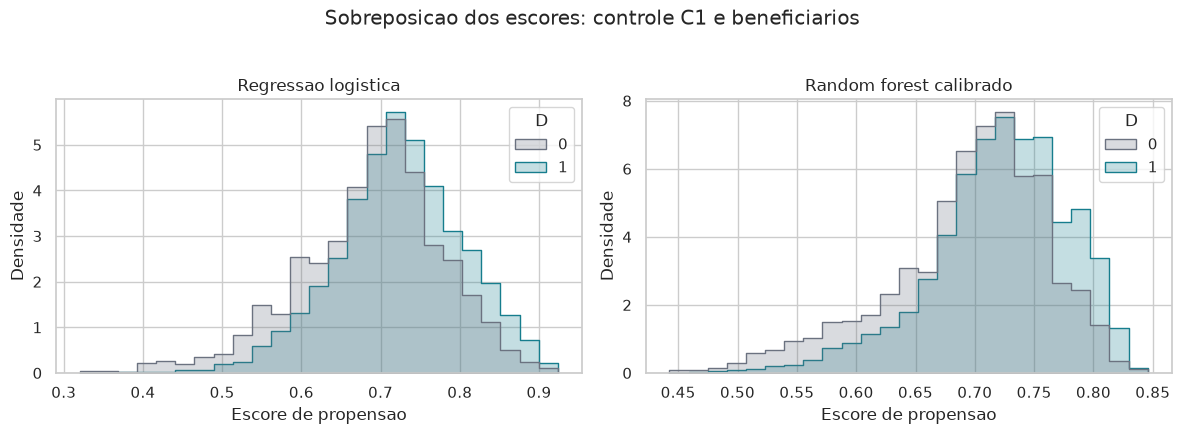

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, (coluna, titulo) in zip(
    axes, [("ps_logit", "Regressao logistica"), ("ps_rf", "Random forest calibrado")]
):
    sns.histplot(data=dados, x=coluna, hue="D", stat="density",
                 common_norm=False, bins=25, element="step", alpha=.25,
                 palette={0: "#6B7280", 1: "#167D8D"}, ax=ax)
    ax.set(title=titulo, xlabel="Escore de propensao", ylabel="Densidade")
fig.suptitle("Sobreposicao dos escores: controle C1 e beneficiarios", y=1.03)
plt.tight_layout()

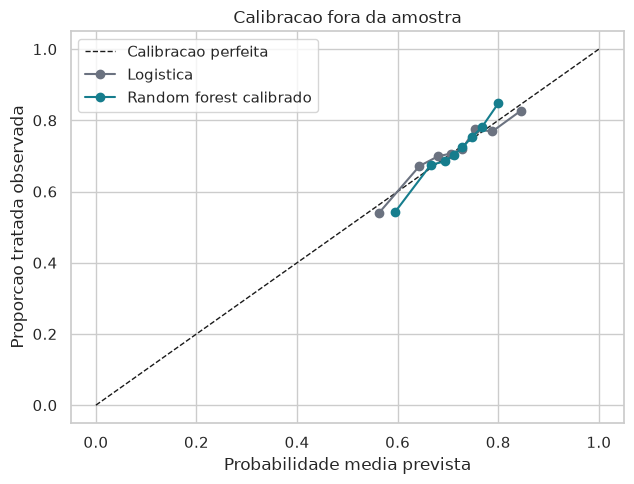

In [7]:
fig, ax = plt.subplots(figsize=(6.5, 5))
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Calibracao perfeita")
for nome, coluna, cor in [
    ("Logistica", "ps_logit", "#6B7280"),
    ("Random forest calibrado", "ps_rf", "#167D8D")
]:
    observado, previsto = calibration_curve(D, dados[coluna], n_bins=8,
                                             strategy="quantile")
    ax.plot(previsto, observado, "o-", color=cor, label=nome)
ax.set(xlabel="Probabilidade media prevista", ylabel="Proporcao tratada observada",
       title="Calibracao fora da amostra")
ax.legend()
plt.tight_layout()

## 4. Metodos para o ATT

Para cada modelo de escore aplicamos:

- **Pareamento 1:1 com reposicao:** cada tratado recebe o controle de escore
  mais proximo. Reposicao e apropriada porque ha menos controles e preserva
  a qualidade dos pares. O peso de um controle e o numero de vezes em que e
  reutilizado.
- **IPW para ATT (Hajek):** tratados recebem peso 1; controles recebem
  `e(X)/(1-e(X))`. As medias ponderadas sao normalizadas dentro dos grupos.

Em ambos os casos restringimos a analise ao suporte comum, definido pela
intersecao dos intervalos observados dos escores nos dois grupos. A
estimativa passa a ser o ATT na populacao tratada com suporte observado.

In [8]:
def suporte_comum(df, ps_col):
    mins = df.groupby("D")[ps_col].min()
    maxs = df.groupby("D")[ps_col].max()
    limite_inf, limite_sup = max(mins), min(maxs)
    mascara = df[ps_col].between(limite_inf, limite_sup)
    return mascara, limite_inf, limite_sup


def estimar_att(df, ps_col):
    mascara, inf, sup = suporte_comum(df, ps_col)
    sub = df.loc[mascara].copy()
    tratado = sub.D.eq(1).to_numpy()
    ps = sub[ps_col].to_numpy()
    y = sub.Y.to_numpy()

    # Pareamento no escore com reposicao.
    pos_trat = np.flatnonzero(tratado)
    pos_ctrl = np.flatnonzero(~tratado)
    nn = NearestNeighbors(n_neighbors=1).fit(ps[pos_ctrl].reshape(-1, 1))
    dist, viz = nn.kneighbors(ps[pos_trat].reshape(-1, 1))
    pos_pareados = pos_ctrl[viz.ravel()]
    att_match = np.mean(y[pos_trat] - y[pos_pareados])
    w_match = np.zeros(len(sub))
    w_match[pos_trat] = 1
    np.add.at(w_match, pos_pareados, 1)

    # IPW/Hajek para ATT. Tratados mantem sua distribuicao; controles a reproduzem.
    w_ipw = np.where(tratado, 1.0, ps / (1 - ps))
    att_ipw = (np.average(y[tratado], weights=w_ipw[tratado])
               - np.average(y[~tratado], weights=w_ipw[~tratado]))

    return {
        "dados": sub, "att_match": att_match, "att_ipw": att_ipw,
        "w_match": w_match, "w_ipw": w_ipw,
        "distancias": dist.ravel(), "limites": (inf, sup),
        "tratados_retidos": int(tratado.sum()),
        "controles_retidos": int((~tratado).sum())
    }


def inferencia_cluster(df, pesos):
    # EP sandwich do contraste de Hajek, agrupado por domicilio.
    # E condicional ao escore: nao incorpora a incerteza de reestima-lo.
    d = df.D.to_numpy().astype(bool)
    y = df.Y.to_numpy()
    w = np.asarray(pesos)
    mu1 = np.average(y[d], weights=w[d])
    mu0 = np.average(y[~d], weights=w[~d])
    influencia = np.zeros(len(df))
    influencia[d] = w[d] * (y[d] - mu1) / w[d].sum()
    influencia[~d] = -w[~d] * (y[~d] - mu0) / w[~d].sum()
    por_dom = pd.Series(influencia).groupby(df.cod_dtm.reset_index(drop=True)).sum()
    g = len(por_dom)
    ep = np.sqrt((g / (g - 1)) * np.square(por_dom).sum())
    return ep


ajustes = {"Logistica": estimar_att(dados, "ps_logit"),
           "Random forest calibrado": estimar_att(dados, "ps_rf")}

linhas = []
for modelo, a in ajustes.items():
    ep_match = inferencia_cluster(a["dados"], a["w_match"])
    ep_ipw = inferencia_cluster(a["dados"], a["w_ipw"])
    linhas.extend([
        {"modelo_escore": modelo, "metodo": "Pareamento 1:1",
         "ATT": a["att_match"], "EP_cluster": ep_match,
         "IC95_inf": a["att_match"] - 1.96 * ep_match,
         "IC95_sup": a["att_match"] + 1.96 * ep_match},
        {"modelo_escore": modelo, "metodo": "IPW-ATT",
         "ATT": a["att_ipw"], "EP_cluster": ep_ipw,
         "IC95_inf": a["att_ipw"] - 1.96 * ep_ipw,
         "IC95_sup": a["att_ipw"] + 1.96 * ep_ipw}
    ])
resultados = pd.DataFrame(linhas)
resultados_pp = resultados.copy()
for coluna in ["ATT", "EP_cluster", "IC95_inf", "IC95_sup"]:
    resultados_pp[coluna + "_pp"] = 100 * resultados_pp[coluna]
resultados_pp[["modelo_escore", "metodo", "ATT_pp", "EP_cluster_pp",
               "IC95_inf_pp", "IC95_sup_pp"]]

,modelo_escore,metodo,ATT_pp,EP_cluster_pp,IC95_inf_pp,IC95_sup_pp
0,Logistica,Pareamento 1:1,-1.5529,1.0098,-3.5321,0.4262
1,Logistica,IPW-ATT,-1.1068,0.7732,-2.6223,0.4087
2,Random forest calibrado,Pareamento 1:1,-2.3298,1.0425,-4.3730,-0.2866
3,Random forest calibrado,IPW-ATT,-1.1149,0.7484,-2.5817,0.3518


In [9]:
def ess(pesos):
    pesos = np.asarray(pesos)
    return pesos.sum() ** 2 / np.square(pesos).sum()

diag_metodos = []
for modelo, a in ajustes.items():
    sub = a["dados"]
    ctrl = sub.D.eq(0).to_numpy()
    diag_metodos.append({
        "modelo": modelo,
        "suporte": f"[{a['limites'][0]:.3f}; {a['limites'][1]:.3f}]",
        "tratados_retidos": a["tratados_retidos"],
        "controles_retidos": a["controles_retidos"],
        "distancia_mediana_match": np.median(a["distancias"]),
        "distancia_max_match": np.max(a["distancias"]),
        "ESS_controles_match": ess(a["w_match"][ctrl]),
        "peso_max_IPW_controle": a["w_ipw"][ctrl].max(),
        "ESS_controles_IPW": ess(a["w_ipw"][ctrl])
    })
pd.DataFrame(diag_metodos)

,modelo,suporte,tratados_retidos,controles_retidos,distancia_mediana_match,distancia_max_match,ESS_controles_match,peso_max_IPW_controle,ESS_controles_IPW
0,Logistica,[0.372; 0.923],6053,2426,0.0000,0.0073,"1,025.6938",12.0350,"1,974.9814"
1,Random forest calibrado,[0.455; 0.843],6052,2429,0.0000,0.0029,"1,065.1633",5.3601,"2,234.0400"


A tabela anterior mostra tambem o tamanho efetivo da amostra (ESS). Ele cai
quando poucos controles recebem grande peso ou sao reutilizados muitas vezes.
Logo, balanceamento excelente pode vir acompanhado de menor precisao; ambos
precisam ser examinados.

## 5. Balanceamento: SMD e love plots

A diferenca padronizada de medias (SMD) mede desequilibrio em unidades de
desvio-padrao. Usamos o desvio-padrao combinado **antes** do ajuste como
denominador fixo, inclusive depois do ajuste. Como regra pratica, `|SMD|<0,1`
e desejavel. Para ATT, comparamos os tratados com a distribuicao reponderada
dos controles.

In [10]:
def media_ponderada(x, w):
    return np.average(np.asarray(x), weights=np.asarray(w))


def tabela_smd(df, pesos=None):
    d = df.D.to_numpy().astype(bool)
    w = np.ones(len(df)) if pesos is None else np.asarray(pesos)
    linhas = []
    for var in COVARIAVEIS:
        x = df[var].to_numpy()
        m1 = media_ponderada(x[d], w[d])
        m0 = media_ponderada(x[~d], w[~d])
        # Denominador pre-ajuste, invariavel entre os diagnosticos.
        sd_pool = np.sqrt((np.var(x[d], ddof=1) + np.var(x[~d], ddof=1)) / 2)
        linhas.append({"covariavel": ROTULOS[var], "SMD": (m1 - m0) / sd_pool})
    return pd.DataFrame(linhas)


smd_antes = tabela_smd(dados).rename(columns={"SMD": "Antes"})
tabelas_smd = []
for modelo, a in ajustes.items():
    base = smd_antes.copy()
    base["Pareamento"] = tabela_smd(a["dados"], a["w_match"])["SMD"]
    base["IPW"] = tabela_smd(a["dados"], a["w_ipw"])["SMD"]
    base.insert(0, "Modelo", modelo)
    tabelas_smd.append(base)
smd_completo = pd.concat(tabelas_smd, ignore_index=True)
smd_completo

,Modelo,covariavel,Antes,Pareamento,IPW
0,Logistica,Idade,-0.0520,-0.0155,0.0046
1,Logistica,Sexo feminino,0.0357,-0.0182,-0.0174
2,Logistica,Escolaridade do chefe,-0.2566,0.0134,0.0115
3,Logistica,Moradores,0.2322,0.0350,-0.0406
4,Logistica,Comodos,-0.1417,0.0176,0.0026
5,Logistica,Dormitorios,-0.0851,0.0133,0.0086
6,Logistica,Agua canalizada,-0.2179,-0.0303,0.0155
7,Random forest calibrado,Idade,-0.0520,-0.0185,-0.0135
8,Random forest calibrado,Sexo feminino,0.0357,0.0069,0.0202
9,Random forest calibrado,Escolaridade do chefe,-0.2566,-0.0354,-0.0881


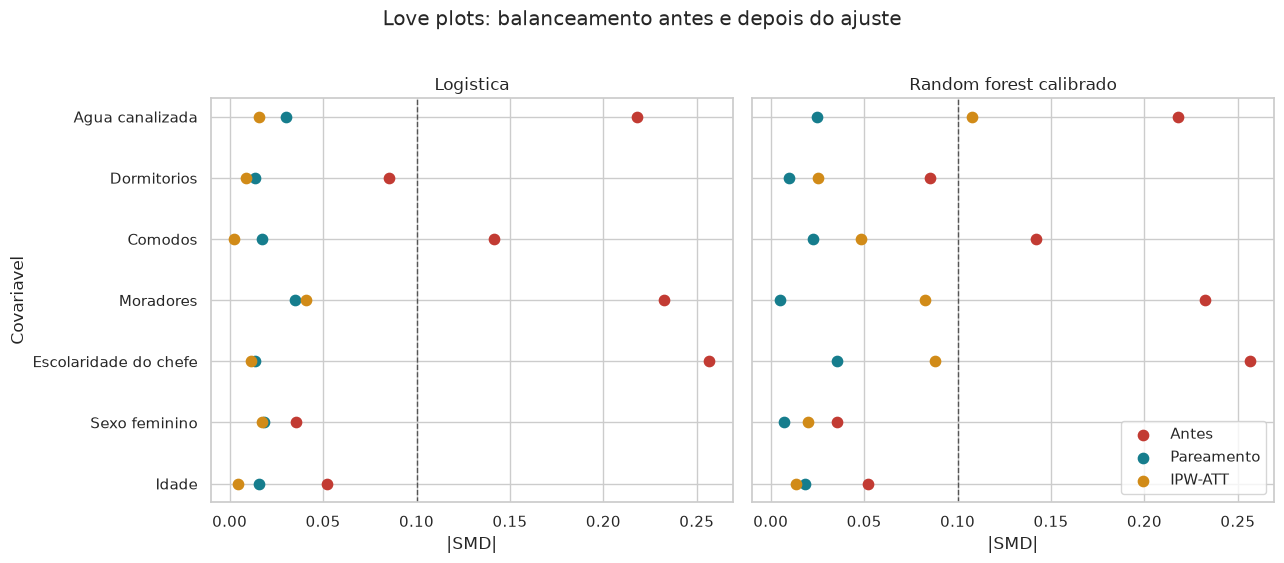

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharex=True, sharey=True)
for ax, (modelo, tab) in zip(axes, smd_completo.groupby("Modelo", sort=False)):
    y = np.arange(len(tab))
    ax.scatter(tab["Antes"].abs(), y, s=55, color=CORES["antes"], label="Antes")
    ax.scatter(tab["Pareamento"].abs(), y, s=55, color=CORES["pareamento"], label="Pareamento")
    ax.scatter(tab["IPW"].abs(), y, s=55, color=CORES["ipw"], label="IPW-ATT")
    ax.axvline(.1, color="#555555", linestyle="--", linewidth=1)
    ax.set_yticks(y, tab["covariavel"])
    ax.set_title(modelo)
    ax.set_xlabel("|SMD|")
    ax.invert_yaxis()
axes[0].set_ylabel("Covariavel")
axes[1].legend(loc="lower right")
fig.suptitle("Love plots: balanceamento antes e depois do ajuste", y=1.02)
plt.tight_layout()

In [12]:
resumo_balanceamento = []
for modelo, tab in smd_completo.groupby("Modelo", sort=False):
    for metodo in ["Antes", "Pareamento", "IPW"]:
        resumo_balanceamento.append({
            "modelo": modelo, "metodo": metodo,
            "max_abs_SMD": tab[metodo].abs().max(),
            "n_acima_0_1": int((tab[metodo].abs() >= .1).sum())
        })
pd.DataFrame(resumo_balanceamento)

,modelo,metodo,max_abs_SMD,n_acima_0_1
0,Logistica,Antes,0.2566,4
1,Logistica,Pareamento,0.0350,0
2,Logistica,IPW,0.0406,0
3,Random forest calibrado,Antes,0.2566,4
4,Random forest calibrado,Pareamento,0.0354,0
5,Random forest calibrado,IPW,0.1079,1


## 6. Sintese e interpretacao

A leitura conjunta segue uma ordem deliberada:

1. verificar sobreposicao e pesos extremos;
2. verificar se o metodo reduziu SMDs para abaixo de 0,1;
3. somente entao comparar os ATTs entre metodos e modelos;
4. interpretar magnitudes em pontos percentuais, sem confundir estabilidade
   entre modelos com prova de identificacao.

Se logistica e random forest produzem resultados proximos e bom
balanceamento, isso mostra **robustez as duas especificacoes observadas do
escore**. Nao mostra que confundidores nao medidos foram eliminados.

In [13]:
tabela_final = resultados_pp[["modelo_escore", "metodo", "ATT_pp",
                              "IC95_inf_pp", "IC95_sup_pp"]].copy()
tabela_final["diferenca_para_bruta_pp"] = tabela_final["ATT_pp"] - 100 * diferenca_bruta
tabela_final.round(3)

,modelo_escore,metodo,ATT_pp,IC95_inf_pp,IC95_sup_pp,diferenca_para_bruta_pp
0,Logistica,Pareamento 1:1,-1.5530,-3.5320,0.4260,-0.5810
1,Logistica,IPW-ATT,-1.1070,-2.6220,0.4090,-0.1350
2,Random forest calibrado,Pareamento 1:1,-2.3300,-4.3730,-0.2870,-1.3580
3,Random forest calibrado,IPW-ATT,-1.1150,-2.5820,0.3520,-0.1430


Os resultados ajustados apontam para reducao da evasao entre os
beneficiarios. O IPW e especialmente estavel a troca do modelo do escore:
cerca de **-1,11 ponto percentual** com logistica ou random forest. O
pareamento e mais sensivel: **-1,55 p.p.** com logistica e **-2,33 p.p.**
com random forest. Essa diferenca e coerente com seu menor ESS de controles
e com a reutilizacao de vizinhos.

Os intervalos de 95% sao aproximacoes normais com erro-padrao agrupado por
domicilio. Eles reconhecem que criancas do mesmo domicilio nao sao
independentes, mas condicionam nos escores estimados e, portanto, podem
subestimar a incerteza total. No modelo principal (logistica + IPW), o IC95%
aproximado e **[-2,62; 0,41] p.p.**: inclui zero, de modo que os dados sao
compativeis tanto com reducao modesta quanto com efeito nulo. A conclusao
deve enfatizar magnitudes, intervalos e robustez, nao uma classificacao
binaria por valor-p.

Nos diagnosticos, a logistica deixa todas as covariaveis abaixo de 0,1 tanto
no pareamento quanto no IPW. O random forest tambem funciona bem no
pareamento, mas seu IPW deixa agua canalizada ligeiramente acima do limiar
(`|SMD|=0,108`). Assim, maior AUC do ML nao implica melhor ajuste causal; a
logistica e o modelo mais convincente nesta aplicacao pelo balanceamento.

O efeito ajustado deve ser descrito como uma diferenca de risco: um ATT de
`-0,01`, por exemplo, equivale a **1 ponto percentual a menos de evasao**
entre beneficiarios, relativamente ao contrafactual estimado sem beneficio.
Nao equivale a uma reducao de 1% no risco relativo.

### O que os diagnosticos podem e nao podem sustentar

SMD baixo confirma equilibrio apenas nas sete covariaveis medidas. Love plot,
AUC e calibracao nao testam ignorabilidade. Renda anterior detalhada,
motivacao dos responsaveis, qualidade da escola, distancia, oferta local e
choques familiares podem afetar simultaneamente recebimento e evasao. Se
algum deles permanecer associado a `D` depois de `X`, o ATT continuara
confundido, ainda que todos os pontos do love plot estejam proximos de zero.

Ha ainda quatro limites substantivos:

- o tratamento domiciliar e uma fotografia, sem duracao ou valor recebido;
- o desfecho e autorrelatado e condicionado a ter estudado no ano anterior;
- criancas do mesmo domicilio nao sao independentes;
- a restricao ao suporte comum limita a conclusao aos beneficiarios
  comparaveis aos controles C1 observados.

Portanto, a formulacao defensavel e: **associacao ajustada compativel com um
ATT causal sob ignorabilidade e demais hipoteses**, e nao prova definitiva
de que o Bolsa Familia causou a mudanca estimada na evasao.

## 7. Conclusao

A analise substituiu o desfecho concentrado de frequencia por evasao escolar,
manteve beneficiarios e controles cadastrados sob um desenho comum e estimou
o ATT por quatro combinacoes de metodo e escore. Pareamento e IPW constroem
contrafactuais de maneiras diferentes; logistica e random forest impõem
estruturas diferentes a probabilidade de tratamento. A convergencia ou
divergencia entre eles deve ser julgada junto com suporte, ESS, SMD e love
plots.

O principal aprendizado nao e escolher o numero mais favoravel. E mostrar
que uma estimativa observacional so ganha interpretacao causal quando o
conjunto de ajuste bloqueia todos os caminhos de confundimento relevantes,
algo que os dados observados nao conseguem verificar por si mesmos.

## Referencias incorporadas a entrega

- BRASIL. Ministerio do Desenvolvimento Social. *Avaliacao de Impacto do
  Programa Bolsa Familia - 2a rodada (AIBF II)*. Brasilia: MDS, 2012.
- DE BRAUW, A. et al. The Impact of Bolsa Familia on Schooling. *World
  Development*, v. 70, p. 303-316, 2015.
- HERNAN, M. A.; ROBINS, J. M. *Causal Inference: What If*. Boca Raton:
  Chapman & Hall/CRC, 2020.
- KING, G.; NIELSEN, R. Why Propensity Scores Should Not Be Used for
  Matching. *Political Analysis*, v. 27, n. 4, p. 435-454, 2019.
- ROSENBAUM, P. R.; RUBIN, D. B. The central role of the propensity score in
  observational studies for causal effects. *Biometrika*, v. 70, n. 1,
  p. 41-55, 1983.

A base analitica e o dicionario minimo estao incluidos em `data/`; nenhuma
conexao externa e necessaria para executar ou avaliar esta entrega.